# 02 — Classificação do MNIST com uma CNN

Treinamos uma **Rede Neural Convolucional (CNN)** no estilo *LeNet* para classificar
os dígitos. Uma CNN aprende **filtros** que detectam padrões locais (bordas, curvas)
e os combina em representações cada vez mais abstratas — muito mais eficiente para
imagens do que uma rede totalmente conectada.

**Metodologia (rígida quanto a vazamento de dados):**
- Treino (60k) dividido em **50k treino + 10k validação**.
- A validação guia o treino e a escolha do melhor modelo.
- O **teste (10k) é usado UMA única vez**, no final — nunca para ajustar nada.

> A matemática de cada operação está documentada em `docs/`.

In [1]:
# ── Setup — funciona igual no seu PC e no Google Colab ───────────────────────
# Ajuste REPO_URL após publicar o projeto no GitHub (ver README).
import sys, os, subprocess
from pathlib import Path

REPO_URL = "https://github.com/4rth-g/mnist-fundamentos-ia.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # No Colab não há o repositório: clonamos para ter o código de src/ e as pastas.
    if not Path("mnist-fundamentos-ia").exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir("mnist-fundamentos-ia")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn"], check=True)

# Torna o pacote src/ importável (local: rodando de notebooks/; Colab: da raiz).
_root = Path.cwd()
_src = _root / "src" if (_root / "src").exists() else _root.parent / "src"
sys.path.insert(0, str(_src))
print("src/ em:", _src)

src/ em: /home/arthurg/Projetos_Dev/mnist-fundamentos-ia/src


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from utils import (seed_everything, get_device, make_dataloaders,
                   MODELS_DIR, FIGURES_DIR)

seed_everything()
device = get_device()

# DataLoaders com a divisão treino/validação/teste correta.
train_loader, val_loader, test_loader = make_dataloaders(batch_size=128, device=device)
print(f"Batches — treino: {len(train_loader)} | val: {len(val_loader)} | teste: {len(test_loader)}")

⚪ Dispositivo: CPU — x86_64
   (nenhuma GPU detectada — o treino será mais lento, mas funciona)
Batches — treino: 391 | val: 40 | teste: 40


## A arquitetura, operação por operação

| Etapa | Operação | Entrada → Saída |
|---|---|---|
| 1 | `Conv2d(1→32, 3×3, pad=1)` + ReLU | `1×28×28` → `32×28×28` |
| 2 | `MaxPool2d(2)` | `32×28×28` → `32×14×14` |
| 3 | `Conv2d(32→64, 3×3, pad=1)` + ReLU | `32×14×14` → `64×14×14` |
| 4 | `MaxPool2d(2)` | `64×14×14` → `64×7×7` |
| 5 | `Flatten` | `64×7×7` → `3136` |
| 6 | `Linear(3136→128)` + ReLU + `Dropout(0.5)` | `3136` → `128` |
| 7 | `Linear(128→10)` | `128` → `10` (logits) |

Cada operação está escrita **explicitamente** no `forward` abaixo, com o formato do
tensor comentado em cada passo. A explicação matemática (convolução, pooling,
ReLU, softmax, entropia cruzada) está em `docs/`.

In [3]:
class CNN(nn.Module):
    """CNN estilo LeNet: 1×28×28 → 10 classes."""

    def __init__(self):
        super().__init__()
        # --- Bloco convolucional (extração de características) ---
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu  = nn.ReLU()
        # --- Bloco totalmente conectado (classificação) ---
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):                 # x: [N, 1, 28, 28]
        x = self.relu(self.conv1(x))      # convolução 1 + ReLU  -> [N, 32, 28, 28]
        x = self.pool(x)                  # sub-amostragem       -> [N, 32, 14, 14]
        x = self.relu(self.conv2(x))      # convolução 2 + ReLU  -> [N, 64, 14, 14]
        x = self.pool(x)                  # sub-amostragem       -> [N, 64, 7, 7]
        x = self.flatten(x)               # achata               -> [N, 3136]
        x = self.relu(self.fc1(x))        # camada densa + ReLU  -> [N, 128]
        x = self.dropout(x)               # regularização (só no treino)
        x = self.fc2(x)                   # camada de saída      -> [N, 10] (logits)
        return x


model = CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParâmetros treináveis: {n_params:,}")

# Teste de sanidade: um lote falso deve sair com formato [4, 10].
dummy = torch.randn(4, 1, 28, 28, device=device)
print(f"Forward de teste: {tuple(model(dummy).shape)}  (esperado: (4, 10))")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Parâmetros treináveis: 421,642
Forward de teste: (4, 10)  (esperado: (4, 10))


## Treino

- **Função de perda:** entropia cruzada (`CrossEntropyLoss`) — padrão para
  classificação multiclasse. Ela já aplica *softmax* internamente, por isso a rede
  devolve *logits* (sem softmax no `forward`).
- **Otimizador:** Adam, `lr = 1e-3`.
- A cada época medimos perda/acurácia em treino e **validação**; guardamos os pesos
  da **melhor época segundo a validação** (`cnn_mnist.pt`).

In [4]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Roda uma época. Se `optimizer` for dado, treina; senão, apenas avalia."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            n += images.size(0)

    return total_loss / n, correct / n

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_path = MODELS_DIR / "cnn_mnist.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss);   history["val_acc"].append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:                 # guarda o melhor modelo (pela validação)
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_path)
        flag = "  <- melhor até agora (salvo)"

    print(f"Época {epoch:2d}/{EPOCHS} | "
          f"treino: loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val: loss {vl_loss:.4f} acc {vl_acc:.4f}{flag}")

print(f"\nMelhor acurácia de validação: {best_val_acc:.4f}  (pesos em {best_path.name})")

Época  1/10 | treino: loss 0.2819 acc 0.9138 | val: loss 0.0690 acc 0.9801  <- melhor até agora (salvo)


Época  2/10 | treino: loss 0.0902 acc 0.9731 | val: loss 0.0613 acc 0.9816  <- melhor até agora (salvo)


Época  3/10 | treino: loss 0.0669 acc 0.9799 | val: loss 0.0487 acc 0.9856  <- melhor até agora (salvo)


Época  4/10 | treino: loss 0.0534 acc 0.9846 | val: loss 0.0435 acc 0.9886  <- melhor até agora (salvo)


Época  5/10 | treino: loss 0.0464 acc 0.9861 | val: loss 0.0421 acc 0.9886


Época  6/10 | treino: loss 0.0410 acc 0.9869 | val: loss 0.0412 acc 0.9886


Época  7/10 | treino: loss 0.0342 acc 0.9895 | val: loss 0.0361 acc 0.9904  <- melhor até agora (salvo)


Época  8/10 | treino: loss 0.0313 acc 0.9904 | val: loss 0.0374 acc 0.9906  <- melhor até agora (salvo)


Época  9/10 | treino: loss 0.0278 acc 0.9912 | val: loss 0.0406 acc 0.9893


Época 10/10 | treino: loss 0.0241 acc 0.9926 | val: loss 0.0438 acc 0.9893

Melhor acurácia de validação: 0.9906  (pesos em cnn_mnist.pt)


## Curvas de aprendizado

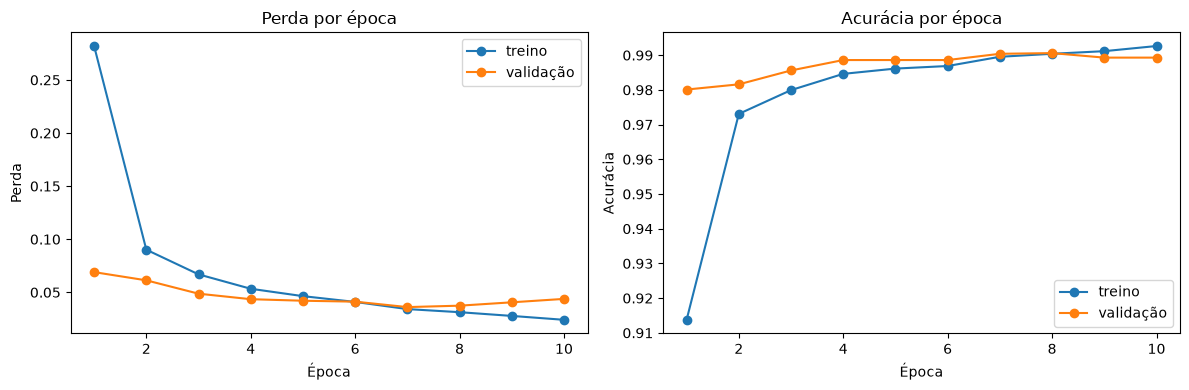

In [6]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], "o-", label="treino")
ax1.plot(epochs, history["val_loss"], "o-", label="validação")
ax1.set(title="Perda por época", xlabel="Época", ylabel="Perda"); ax1.legend()

ax2.plot(epochs, history["train_acc"], "o-", label="treino")
ax2.plot(epochs, history["val_acc"], "o-", label="validação")
ax2.set(title="Acurácia por época", xlabel="Época", ylabel="Acurácia"); ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curvas_aprendizado.png", dpi=120)
plt.show()

## Avaliação final no conjunto de TESTE (uma única vez)

Só agora, com o modelo já escolhido pela validação, tocamos no conjunto de teste.
Isso garante que a acurácia reportada seja uma **estimativa honesta** do desempenho
em dados nunca vistos.

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Recarrega os melhores pesos (a melhor época segundo a validação).
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(labels)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_acc = (all_preds == all_labels).mean()
print(f"Acurácia no TESTE: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, digits=4,
                            target_names=[str(i) for i in range(10)]))

Acurácia no TESTE: 0.9916

              precision    recall  f1-score   support

           0     0.9889    0.9959    0.9924       980
           1     0.9965    0.9974    0.9969      1135
           2     0.9894    0.9922    0.9908      1032
           3     0.9911    0.9960    0.9936      1010
           4     0.9969    0.9908    0.9939       982
           5     0.9899    0.9865    0.9882       892
           6     0.9979    0.9823    0.9900       958
           7     0.9941    0.9893    0.9917      1028
           8     0.9818    0.9969    0.9893       974
           9     0.9891    0.9871    0.9881      1009

    accuracy                         0.9916     10000
   macro avg     0.9916    0.9915    0.9915     10000
weighted avg     0.9916    0.9916    0.9916     10000



## Matriz de confusão

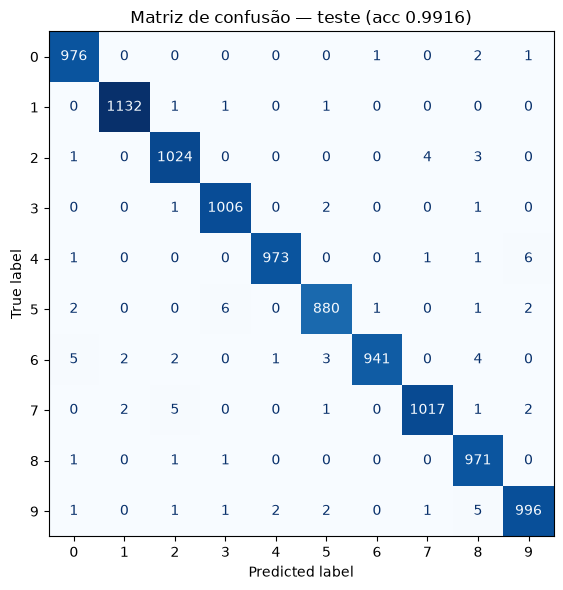

In [8]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusão — teste (acc {test_acc:.4f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "matriz_confusao.png", dpi=120)
plt.show()

## Alguns erros do modelo\n\nOlhar os erros ajuda a entender as limitações — muitos são dígitos ambíguos até para humanos.

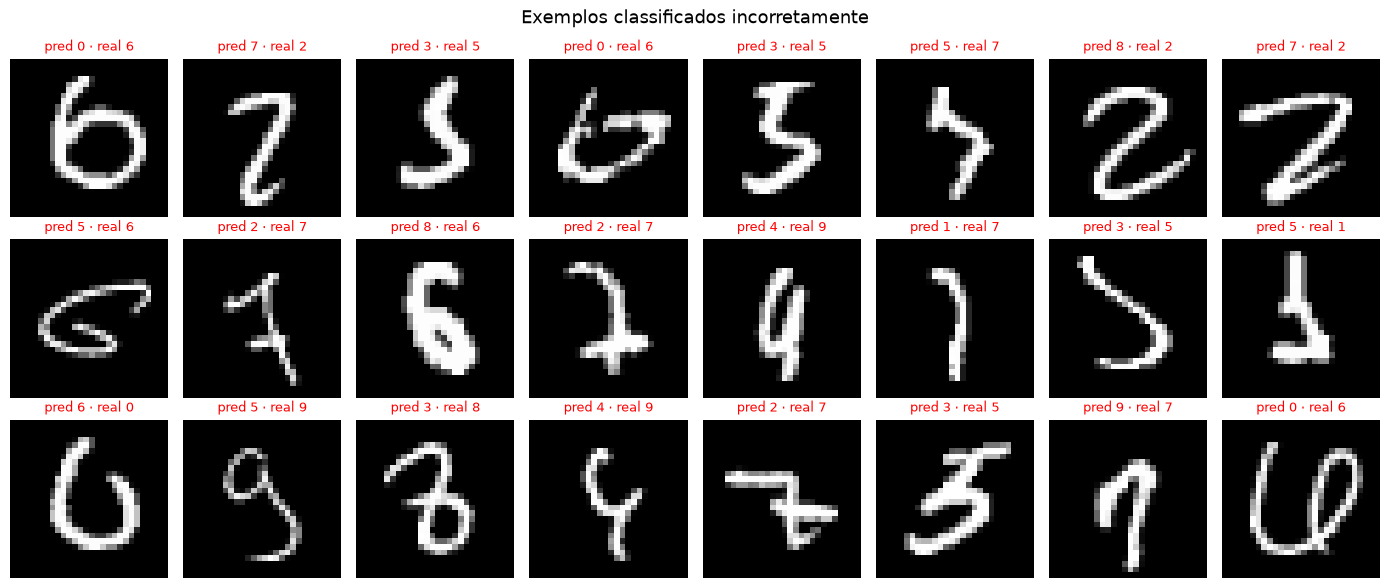

In [9]:
errors = np.where(all_preds != all_labels)[0][:24]
# Recarrega o teste sem normalização só para exibir as imagens de forma legível.
from utils import load_mnist
_, test_vis = load_mnist(normalize=False)

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for ax, idx in zip(axes.flat, errors):
    ax.imshow(test_vis[idx][0].squeeze(), cmap="gray")
    ax.set_title(f"pred {all_preds[idx]} · real {all_labels[idx]}", color="red", fontsize=9)
    ax.axis("off")
fig.suptitle("Exemplos classificados incorretamente", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "erros_classificacao.png", dpi=120)
plt.show()

## Conclusão

A CNN atinge cerca de **99% de acurácia no teste** — excelente para um modelo tão
simples e treinado em poucos minutos. Pontos-chave do trabalho:

- **Convolução + pooling** exploram a estrutura espacial da imagem, superando de
  longe uma rede totalmente conectada.
- A **separação treino/validação/teste** garante que o número reportado seja honesto.
- Os erros restantes são, em geral, dígitos genuinamente ambíguos.